# Exoplanet Analysis Tools — 03: Radial velocities of TOI-3568

In this notebook we analyze the radial velocities of TOI-3568 from
Martioli et al. (2024): 33 MAROON-X blue-arm points, 33 MAROON-X red-arm points,
and 5 nightly-binned SPIRou points.

In [1]:
%matplotlib inline
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
from exoplanet_analysis import fitlib, rvutils, timeseries_lib

DATA = "data/TOI-3568/"
os.makedirs("outputs", exist_ok=True)
priors_file = "outputs/TOI-3568_rv.pars"
shutil.copyfile(DATA + "TOI-3568.pars", priors_file)

'outputs/TOI-3568_rv.pars'

## 1. Load the RV data

RV time series are stored in `.rdb` files with columns `rjd` (RJD = BJD − 2400000),
`vrad` and `svrad` (km/s). `rvutils.read_rv_time_series` converts times to BJD and
velocities to m/s (`conv_factor=1000`). Note that each instrument has its own zero
point — MAROON-X delivers *relative* RVs (≈ 0 m/s) while SPIRou delivers *absolute*
RVs (≈ −97.7 km/s); the fit handles one systemic-velocity coefficient per dataset.

In [2]:
rv_files = [DATA + "TOI-3568_maroon-x_blue.rdb",
            DATA + "TOI-3568_maroon-x_red.rdb",
            DATA + "TOI-3568_spirou_binned.rdb"]
labels = ["MAROON-X blue", "MAROON-X red", "SPIRou (binned)"]

bjds, rvs, rverrs = [], [], []
for f in rv_files:
    bjd, rv, rverr = rvutils.read_rv_time_series(f, conv_factor=1000.)   # -> m/s
    bjds.append(bjd); rvs.append(rv); rverrs.append(rverr)
    print("{:18s}: {:2d} points | median RV {:10.2f} m/s | median error {:5.2f} m/s".format(
        labels[len(bjds)-1], len(bjd), np.median(rv), np.median(rverr)))

MAROON-X blue     : 33 points | median RV      -2.09 m/s | median error  1.93 m/s
MAROON-X red      : 33 points | median RV      -1.71 m/s | median error  3.42 m/s
SPIRou (binned)   :  5 points | median RV  -97661.10 m/s | median error 12.45 m/s


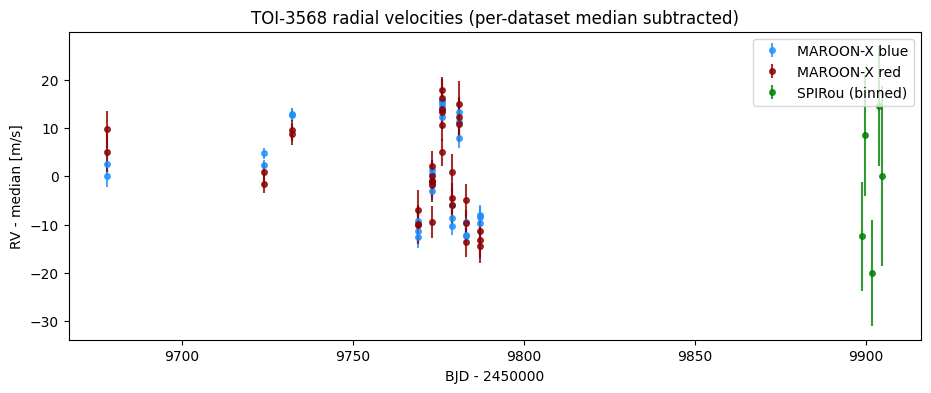

In [3]:
colors = ["dodgerblue", "darkred", "green"]
plt.figure(figsize=(11, 4))
for i in range(len(rvs)):
    plt.errorbar(bjds[i] - 2450000, rvs[i] - np.median(rvs[i]), yerr=rverrs[i],
                 fmt="o", ms=4, color=colors[i], label=labels[i], alpha=0.8)
plt.xlabel("BJD - 2450000"); plt.ylabel("RV - median [m/s]")
plt.title("TOI-3568 radial velocities (per-dataset median subtracted)")
plt.legend(); plt.show()

## 2. GLS periodogram

Before fitting, let's verify that the orbital period of the transiting planet
(P ≈ 4.418 d) is present in the RV data with a Generalized Lomb–Scargle periodogram: 

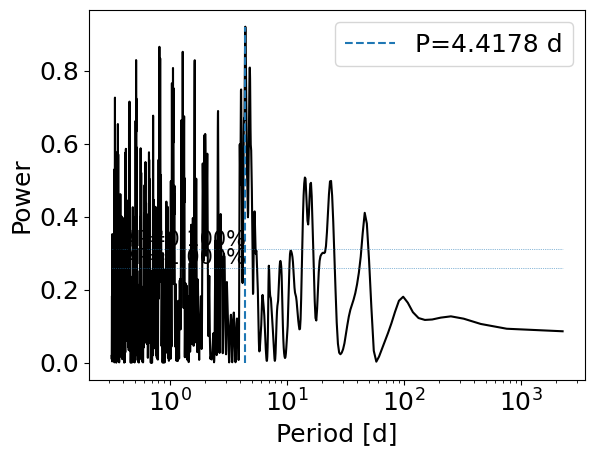

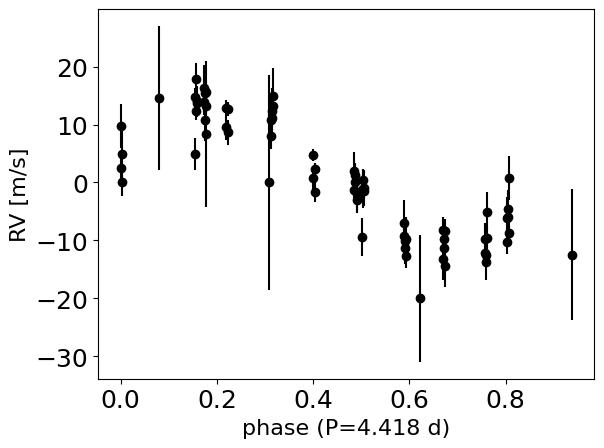

In [4]:
all_bjd = np.concatenate(bjds)
all_rv = np.concatenate([rv - np.median(rv) for rv in rvs])
all_err = np.concatenate(rverrs)

gls = timeseries_lib.periodogram(all_bjd, all_rv, all_err, period=4.4178490108,
                                 y_label="RV [m/s]", phaseplot=True, plot=True)

## 3. Keplerian orbit fit (OLS + MCMC)

The RV fit follows the same priors file as the transit fit. The steps are:
`read_rv_priors` → `guess_rvcalib` (initial per-dataset systemic velocities) →
`fit_RVs_ols` (least-squares refinement) → `fitRVsWithMCMC` (posterior sampling).
The free parameters here are `k`, `tc`, `per` and one RV offset per dataset.

In [5]:
priors = fitlib.read_rv_priors(priors_file, len(rvs), verbose=False)
posterior = fitlib.guess_rvcalib(priors, bjds, rvs, prior_type="Normal", plot=False)
print("free parameters:", posterior["labels"])

# least-squares refinement of the initial guess
posterior = fitlib.fit_RVs_ols(bjds, rvs, rverrs, posterior, fix_eccentricity=True,
                               rvcalib_post_type="Normal", calib_unc=0.01,
                               verbose=False, plot=False)

median_rv (no prior model considered) =  -2.09
median_rv= -0.760143012651088
median_rv (no prior model considered) =  -1.71
median_rv= -0.12984628284661603
median_rv (no prior model considered) =  -97661.1037544854
median_rv= -97670.43726352761
free parameters: ['k_000', 'tc_000', 'per_000', 'rv_d00', 'rv_d01', 'rv_d02']
Free parameters before OLS fit:
k_000 = 12.0213119413
tc_000 = 2459799.3828418534
per_000 = 4.4178490108
rv_d00 = -0.760143012651088
rv_d01 = -0.12984628284661603
rv_d02 = -97670.43726352761
Free parameters after OLS fit:
k_000 = 12.0213119413
tc_000 = 2459799.3828418534
per_000 = 4.4178490108
rv_d00 = -0.8945086294848901
rv_d01 = -1.3527634190249165
rv_d02 = -97666.28875813668


In [6]:
posterior = fitlib.fitRVsWithMCMC(bjds, rvs, rverrs, posterior,
                                  nwalkers=32, niter=2000, burnin=600,
                                  samples_filename="outputs/TOI-3568_rv_samples.h5",
                                  rvdatalabels=labels, verbose=True, plot=False)

Free parameters before MCMC fit:
k_000 = 12.0213119413
tc_000 = 2459799.3828418534
per_000 = 4.4178490108
rv_d00 = -0.8945086294848901
rv_d01 = -1.3527634190249165
rv_d02 = -97666.28875813668
initializing emcee sampler ...
Running MCMC ...
N_walkers= 32  ndim= 6


  0%|          | 0/2000 [00:00<?, ?it/s]

  1%|          | 12/2000 [00:00<00:16, 118.71it/s]

  1%|▏         | 25/2000 [00:00<00:15, 125.00it/s]

  2%|▏         | 38/2000 [00:00<00:15, 126.70it/s]

...

 99%|█████████▊| 1973/2000 [00:15<00:00, 124.00it/s]

 99%|█████████▉| 1986/2000 [00:15<00:00, 123.15it/s]

100%|█████████▉| 1999/2000 [00:15<00:00, 122.44it/s]

100%|██████████| 2000/2000 [00:15<00:00, 125.37it/s]

Obtaining best fit RV calibration parameters from pdfs ...
RV CALIBRATION Fit parameters:
rv_d00 = -0.915531819920964 + 0.31459533663758443 - 0.31666660811682157
rv_d01 = -1.3499467315056066 + 0.5156072165809994 - 0.5429819018638669
rv_d02 = -97666.91071430997 + 5.7401691452396335 - 5.514146237808745
----------------
Output RV CALIBRATION posterior:  rv_calibration_posterior.pars
Obtaining best fit planet parameters from pdfs ...
----------------
PLANET 2 Fit parameters:
k_000 = 11.969356885540282 + 0.35255032133913744 - 0.34682354789475056
tc_000 = 2459799.360892253 + 0.028707146644592285 - 0.028998115565627813
per_000 = 4.418356482664333 + 0.0012218145772493472 - 0.0017636289925793136
----------------
Output PLANET posterior:  outputs/TOI-3568_rv_posterior.pars


## 4. Phase-folded orbit

`fitlib` provides ready-made plotting utilities for the fitted orbit — the phase-folded
RV curve for the planet, with the per-dataset systemic velocities removed: 

RMS of RV residuals: 3.45 m/s
Reduced chi-square (n=5, DOF=-1): -1.31


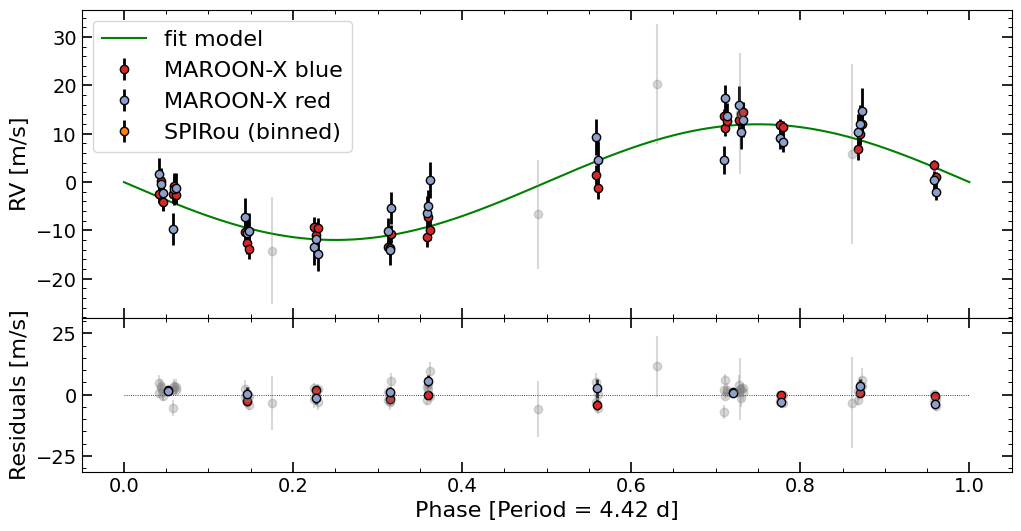

In [7]:
fitlib.plot_rv_perplanet_timeseries(posterior["planet_params"], posterior["rvcalib_params"],
                                    bjds, rvs, rverrs,
                                    number_of_free_params=len(posterior["theta"]),
                                    planet_index=0, nsamples=100, plot_residuals=True,
                                    rvdatalabels=labels, phase_plot=True, bindata=True, binsize=0.05)

## 5. Results

Compare with Martioli et al. (2024): $K = 11.9 \pm 1.7$ m/s, implying
$M_p = 26.4 \pm 5.0\,M_\oplus$. The posterior files are in `outputs/`
(`TOI-3568_rv_posterior.pars` and its `.json` mirror).

In [8]:
print(open("outputs/TOI-3568_rv_posterior.pars").read())

# Parameter_ID	Prior_Type	Values
teff	FIXED	4960.0
ms	FIXED	0.776
rs	FIXED	0.719
n_planets	FIXED	1.0
k_000	Normal	11.9693568855,0.3496869346
tc_000	Normal	2459799.3608922530,0.0288526311
per_000	Normal	4.4183564827,0.0014927218
rvsys_000	FIXED	0.0
trend_000	FIXED	0.0
quadtrend_000	FIXED	0.0

